# 02 - Performance Analysis
Deep dive into model performance across networks and regions.

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', None)
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [4]:
# Setup paths
PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
ANALYSIS_DIR = PROJECT_ROOT / 'data' / 'analysis'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'performance'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Analysis Directory: {ANALYSIS_DIR}")
print(f"Figures Directory: {FIGURES_DIR}")

Analysis Directory: /home/sjoon/projects/brain_connectivity_classifier/data/analysis
Figures Directory: /home/sjoon/projects/brain_connectivity_classifier/figures/performance


## 1. Load Compiled Results

In [53]:
# Load compiled data
cv_perf = pd.read_csv(ANALYSIS_DIR / 'compiled_cv_performance.csv')
task_perf = pd.read_csv(ANALYSIS_DIR / 'compiled_task_performance.csv')
network_perf = pd.read_csv(ANALYSIS_DIR / 'compiled_network_performance.csv')
region_perf = pd.read_csv(ANALYSIS_DIR / 'compiled_region_performance.csv')
perf_drop = pd.read_csv(ANALYSIS_DIR / 'performance_drop_cv_to_task.csv')

print("Loaded data shapes:")
print(f"  CV Performance: {cv_perf.shape}")
print(f"  Task Performance: {task_perf.shape}")
print(f"  Network Performance: {network_perf.shape}")
print(f"  Region Performance: {region_perf.shape}")
print(f"  Performance Drop: {perf_drop.shape}")

Loaded data shapes:
  CV Performance: (9, 11)
  Task Performance: (9, 9)
  Network Performance: (198, 7)
  Region Performance: (1392, 9)
  Performance Drop: (9, 8)


In [77]:
# Quick data quality check
print("="*80)
print("DATA QUALITY CHECK")
print("="*80)

print("\n1. CV Performance Range:")
print(f"   Accuracy: {cv_perf['Accuracy'].min():.3f} - {cv_perf['Accuracy'].max():.3f}")

print("\n2. Task Performance Range:")
print(f"   Accuracy: {task_perf['Accuracy'].min():.3f} - {task_perf['Accuracy'].max():.3f}")

print("\n3. Performance Drop Range:")
print(f"   Accuracy Drop: {perf_drop['Accuracy_Drop'].min():.3f} - {perf_drop['Accuracy_Drop'].max():.3f}")

print("\n4. Number of Networks:")
print(f"   Unique networks: {network_perf['network'].nunique()}")

print("\n5. Number of Regions:")
print(f"   Unique regions: {region_perf['region_name'].nunique()}")

print("\n✓ Data quality check complete")

DATA QUALITY CHECK

1. CV Performance Range:
   Accuracy: 0.869 - 0.932

2. Task Performance Range:
   Accuracy: 0.824 - 0.896

3. Performance Drop Range:
   Accuracy Drop: 0.032 - 0.052

4. Number of Networks:
   Unique networks: 33

5. Number of Regions:
   Unique regions: 232

✓ Data quality check complete


## 2. Overall Performance Summary

In [78]:
# Create comprehensive summary statistics
print("="*80)
print("OVERALL PERFORMANCE SUMMARY")
print("="*80)

summary_stats = []

for idx, row in cv_perf.iterrows():
    # Get matching task performance
    task_row = task_perf[(task_perf['Analysis'] == row['Analysis']) & 
                         (task_perf['Strategy'] == row['Strategy'])]
    
    if not task_row.empty:
        summary_stats.append({
            'Analysis': row['Analysis'],
            'Strategy': row['Strategy'],
            'CV_Accuracy': row['Accuracy'],
            'CV_Std': row['Accuracy_Std'],
            'Task_Accuracy': task_row['Accuracy'].values[0],
            'Drop': row['Accuracy'] - task_row['Accuracy'].values[0],
            'Top_5_CV': row['Top_5_Accuracy'],
            'Top_5_Task': task_row['Top_5_Accuracy'].values[0]
        })

summary_df = pd.DataFrame(summary_stats)

# Display
print("\nPerformance Summary (All Conditions):")
print(summary_df.to_string(index=False))

# Save
summary_df.to_csv(ANALYSIS_DIR / 'overall_performance_summary.csv', index=False)
print(f"\n✓ Saved to: {ANALYSIS_DIR / 'overall_performance_summary.csv'}")

OVERALL PERFORMANCE SUMMARY

Performance Summary (All Conditions):
         Analysis    Strategy  CV_Accuracy   CV_Std  Task_Accuracy     Drop  Top_5_CV  Top_5_Task
Full Connectivity MULTINOMIAL     0.924126 0.002439       0.892392 0.031734  0.983336    0.972608
Full Connectivity         OVO     0.868785 0.003630       0.830496 0.038289  0.961573    0.000000
Full Connectivity         OVR     0.931708 0.001876       0.896336 0.035372  0.983721    0.970711
  Left Hemisphere MULTINOMIAL     0.918180 0.004778       0.869310 0.048870  0.982682    0.970388
  Left Hemisphere         OVO     0.881427 0.007082       0.835862 0.045565  0.970251    0.954138
  Left Hemisphere         OVR     0.922645 0.004891       0.875690 0.046955  0.983721    0.969095
 Right Hemisphere MULTINOMIAL     0.913562 0.002358       0.863060 0.050502  0.982066    0.965690
 Right Hemisphere         OVO     0.875269 0.004479       0.823578 0.051692  0.967480    0.948578
 Right Hemisphere         OVR     0.920836 0.002929

In [79]:
# Identify best performers
print("\n" + "="*80)
print("BEST PERFORMING CONFIGURATIONS")
print("="*80)

print("\n1. Best CV Performance:")
best_cv = summary_df.loc[summary_df['CV_Accuracy'].idxmax()]
print(f"   {best_cv['Analysis']} - {best_cv['Strategy']}")
print(f"   Accuracy: {best_cv['CV_Accuracy']:.4f} ± {best_cv['CV_Std']:.4f}")

print("\n2. Best Task Performance:")
best_task = summary_df.loc[summary_df['Task_Accuracy'].idxmax()]
print(f"   {best_task['Analysis']} - {best_task['Strategy']}")
print(f"   Accuracy: {best_task['Task_Accuracy']:.4f}")

print("\n3. Best Generalization (Smallest Drop):")
best_gen = summary_df.loc[summary_df['Drop'].idxmin()]
print(f"   {best_gen['Analysis']} - {best_gen['Strategy']}")
print(f"   Drop: {best_gen['Drop']:.4f}")

print("\n4. Worst Generalization (Largest Drop):")
worst_gen = summary_df.loc[summary_df['Drop'].idxmax()]
print(f"   {worst_gen['Analysis']} - {worst_gen['Strategy']}")
print(f"   Drop: {worst_gen['Drop']:.4f} (Most Reorganization)")


BEST PERFORMING CONFIGURATIONS

1. Best CV Performance:
   Full Connectivity - OVR
   Accuracy: 0.9317 ± 0.0019

2. Best Task Performance:
   Full Connectivity - OVR
   Accuracy: 0.8963

3. Best Generalization (Smallest Drop):
   Full Connectivity - MULTINOMIAL
   Drop: 0.0317

4. Worst Generalization (Largest Drop):
   Right Hemisphere - OVO
   Drop: 0.0517 (Most Reorganization)


## 3. Strategy Comparison Analysis

In [80]:
# Compare strategies across all analyses
print("="*80)
print("STRATEGY COMPARISON ANALYSIS")
print("="*80)

# Group by strategy
strategy_comparison = summary_df.groupby('Strategy').agg({
    'CV_Accuracy': ['mean', 'std'],
    'Task_Accuracy': ['mean', 'std'],
    'Drop': ['mean', 'std']
}).round(4)

strategy_comparison.columns = ['_'.join(col).strip() for col in strategy_comparison.columns.values]

print("\nStrategy Performance Across All Analyses:")
print(strategy_comparison)

# Ranking
print("\n" + "-"*80)
print("STRATEGY RANKING:")
print("-"*80)
print("\nBy CV Accuracy:")
cv_rank = summary_df.groupby('Strategy')['CV_Accuracy'].mean().sort_values(ascending=False)
for i, (strategy, acc) in enumerate(cv_rank.items(), 1):
    print(f"  {i}. {strategy}: {acc:.4f}")

print("\nBy Task Accuracy:")
task_rank = summary_df.groupby('Strategy')['Task_Accuracy'].mean().sort_values(ascending=False)
for i, (strategy, acc) in enumerate(task_rank.items(), 1):
    print(f"  {i}. {strategy}: {acc:.4f}")

print("\nBy Generalization (Smallest Drop):")
gen_rank = summary_df.groupby('Strategy')['Drop'].mean().sort_values(ascending=True)
for i, (strategy, drop) in enumerate(gen_rank.items(), 1):
    print(f"  {i}. {strategy}: {drop:.4f}")

STRATEGY COMPARISON ANALYSIS

Strategy Performance Across All Analyses:
             CV_Accuracy_mean  CV_Accuracy_std  Task_Accuracy_mean  \
Strategy                                                             
MULTINOMIAL            0.9186           0.0053              0.8749   
OVO                    0.8752           0.0063              0.8300   
OVR                    0.9251           0.0058              0.8810   

             Task_Accuracy_std  Drop_mean  Drop_std  
Strategy                                             
MULTINOMIAL             0.0154     0.0437    0.0104  
OVO                     0.0062     0.0452    0.0067  
OVR                     0.0135     0.0440    0.0076  

--------------------------------------------------------------------------------
STRATEGY RANKING:
--------------------------------------------------------------------------------

By CV Accuracy:
  1. OVR: 0.9251
  2. MULTINOMIAL: 0.9186
  3. OVO: 0.8752

By Task Accuracy:
  1. OVR: 0.8810
  2. MULTINOMI

In [81]:
# Statistical tests between strategies
print("\n" + "="*80)
print("STATISTICAL TESTS: STRATEGY COMPARISON")
print("="*80)

# For Full Connectivity only (most reliable)
full_conn = summary_df[summary_df['Analysis'] == 'Full Connectivity']

strategies = ['MULTINOMIAL', 'OVO', 'OVR']
print("\nPairwise Comparisons (CV Accuracy):")
print("-"*80)

for i in range(len(strategies)):
    for j in range(i+1, len(strategies)):
        s1, s2 = strategies[i], strategies[j]
        acc1 = full_conn[full_conn['Strategy'] == s1]['CV_Accuracy'].values[0]
        acc2 = full_conn[full_conn['Strategy'] == s2]['CV_Accuracy'].values[0]
        
        diff = acc1 - acc2
        print(f"\n{s1} vs {s2}:")
        print(f"  {s1}: {acc1:.4f}")
        print(f"  {s2}: {acc2:.4f}")
        print(f"  Difference: {diff:.4f} ({'+' if diff > 0 else ''}{diff*100:.2f}%)")
        
        if abs(diff) > 0.01:
            print(f"  → Practically significant difference (>1%)")
        else:
            print(f"  → Minor difference (<1%)")


STATISTICAL TESTS: STRATEGY COMPARISON

Pairwise Comparisons (CV Accuracy):
--------------------------------------------------------------------------------

MULTINOMIAL vs OVO:
  MULTINOMIAL: 0.9241
  OVO: 0.8688
  Difference: 0.0553 (+5.53%)
  → Practically significant difference (>1%)

MULTINOMIAL vs OVR:
  MULTINOMIAL: 0.9241
  OVR: 0.9317
  Difference: -0.0076 (-0.76%)
  → Minor difference (<1%)

OVO vs OVR:
  OVO: 0.8688
  OVR: 0.9317
  Difference: -0.0629 (-6.29%)
  → Practically significant difference (>1%)



✓ Saved strategy comparison plot


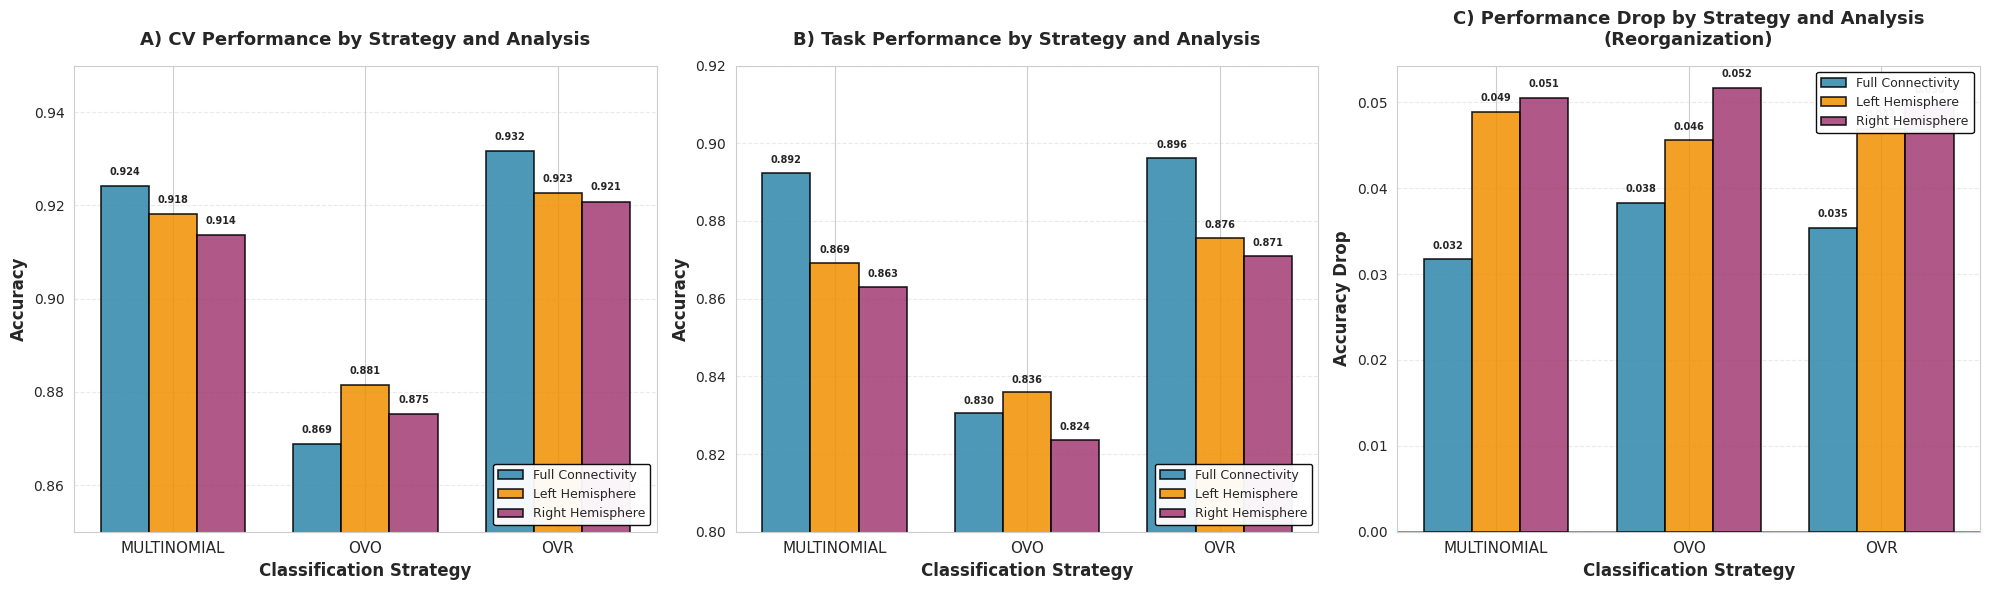

In [105]:
# Visualize strategy comparison with all analyses
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define colors for each analysis type
analysis_colors = {
    'Full Connectivity': '#2E86AB',
    'Left Hemisphere': '#F18F01', 
    'Right Hemisphere': '#A23B72'
}

strategies = ['MULTINOMIAL', 'OVO', 'OVR']
analyses = ['Full Connectivity', 'Left Hemisphere', 'Right Hemisphere']
x = np.arange(len(strategies))
width = 0.25  # Width of bars

# Plot 1: CV Accuracy by Strategy and Analysis
ax = axes[0]
for i, analysis in enumerate(analyses):
    analysis_data = summary_df[summary_df['Analysis'] == analysis]
    values = [analysis_data[analysis_data['Strategy'] == s]['CV_Accuracy'].values[0] 
              for s in strategies]
    
    bars = ax.bar(x + i*width, values, width, 
                  label=analysis, color=analysis_colors[analysis],
                  edgecolor='black', linewidth=1.2, alpha=0.85)
    
    # Add value labels
    for j, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, 
                f'{val:.3f}', ha='center', va='bottom', 
                fontsize=7, fontweight='bold', rotation=0)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Strategy', fontsize=12, fontweight='bold')
ax.set_title('A) CV Performance by Strategy and Analysis', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylim([0.85, 0.95])
ax.legend(fontsize=9, loc='lower right', framealpha=0.95, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--')

# Plot 2: Task Accuracy by Strategy and Analysis
ax = axes[1]
for i, analysis in enumerate(analyses):
    analysis_data = summary_df[summary_df['Analysis'] == analysis]
    values = [analysis_data[analysis_data['Strategy'] == s]['Task_Accuracy'].values[0] 
              for s in strategies]
    
    bars = ax.bar(x + i*width, values, width, 
                  label=analysis, color=analysis_colors[analysis],
                  edgecolor='black', linewidth=1.2, alpha=0.85)
    
    # Add value labels
    for j, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.002, 
                f'{val:.3f}', ha='center', va='bottom', 
                fontsize=7, fontweight='bold', rotation=0)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Strategy', fontsize=12, fontweight='bold')
ax.set_title('B) Task Performance by Strategy and Analysis', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylim([0.80, 0.92])
ax.legend(fontsize=9, loc='lower right', framealpha=0.95, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--')

# Plot 3: Performance Drop by Strategy and Analysis
ax = axes[2]
for i, analysis in enumerate(analyses):
    analysis_data = summary_df[summary_df['Analysis'] == analysis]
    values = [analysis_data[analysis_data['Strategy'] == s]['Drop'].values[0] 
              for s in strategies]
    
    bars = ax.bar(x + i*width, values, width, 
                  label=analysis, color=analysis_colors[analysis],
                  edgecolor='black', linewidth=1.2, alpha=0.85)
    
    # Add value labels
    for j, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.001, 
                f'{val:.3f}', ha='center', va='bottom', 
                fontsize=7, fontweight='bold', rotation=0)

ax.set_ylabel('Accuracy Drop', fontsize=12, fontweight='bold')
ax.set_xlabel('Classification Strategy', fontsize=12, fontweight='bold')
ax.set_title('C) Performance Drop by Strategy and Analysis\n(Reorganization)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(strategies, fontsize=11)
ax.axhline(y=0, color='red', linestyle='-', linewidth=2, alpha=0.7, zorder=0)
ax.legend(fontsize=9, loc='upper right', framealpha=0.95, edgecolor='black')
ax.grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'strategy_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'strategy_comparison_comprehensive.pdf', bbox_inches='tight')
print("\n✓ Saved strategy comparison plot")
plt.show()

## 4. Hemisphere Analysis

In [83]:
# Hemisphere analysis
print("\n" + "="*80)
print("HEMISPHERE ANALYSIS")
print("="*80)

# Filter hemisphere data
left_hemi = summary_df[summary_df['Analysis'] == 'Left Hemisphere']
right_hemi = summary_df[summary_df['Analysis'] == 'Right Hemisphere']

print("\nLeft Hemisphere Performance:")
print(left_hemi[['Strategy', 'CV_Accuracy', 'Task_Accuracy', 'Drop']].to_string(index=False))

print("\nRight Hemisphere Performance:")
print(right_hemi[['Strategy', 'CV_Accuracy', 'Task_Accuracy', 'Drop']].to_string(index=False))

# Average across strategies
print("\n" + "-"*80)
print("AVERAGE PERFORMANCE (across all strategies):")
print("-"*80)
print(f"\nLeft Hemisphere:")
print(f"  CV Accuracy:   {left_hemi['CV_Accuracy'].mean():.4f} ± {left_hemi['CV_Accuracy'].std():.4f}")
print(f"  Task Accuracy: {left_hemi['Task_Accuracy'].mean():.4f} ± {left_hemi['Task_Accuracy'].std():.4f}")
print(f"  Drop:          {left_hemi['Drop'].mean():.4f} ± {left_hemi['Drop'].std():.4f}")

print(f"\nRight Hemisphere:")
print(f"  CV Accuracy:   {right_hemi['CV_Accuracy'].mean():.4f} ± {right_hemi['CV_Accuracy'].std():.4f}")
print(f"  Task Accuracy: {right_hemi['Task_Accuracy'].mean():.4f} ± {right_hemi['Task_Accuracy'].std():.4f}")
print(f"  Drop:          {right_hemi['Drop'].mean():.4f} ± {right_hemi['Drop'].std():.4f}")

# Difference
print("\n" + "-"*80)
print("HEMISPHERE DIFFERENCES (Left - Right):")
print("-"*80)
cv_diff = left_hemi['CV_Accuracy'].mean() - right_hemi['CV_Accuracy'].mean()
task_diff = left_hemi['Task_Accuracy'].mean() - right_hemi['Task_Accuracy'].mean()
drop_diff = left_hemi['Drop'].mean() - right_hemi['Drop'].mean()

print(f"  CV Accuracy:   {cv_diff:+.4f} ({'Left' if cv_diff > 0 else 'Right'} better)")
print(f"  Task Accuracy: {task_diff:+.4f} ({'Left' if task_diff > 0 else 'Right'} better)")
print(f"  Drop:          {drop_diff:+.4f} ({'Left' if drop_diff > 0 else 'Right'} more stable)")


HEMISPHERE ANALYSIS

Left Hemisphere Performance:
   Strategy  CV_Accuracy  Task_Accuracy     Drop
MULTINOMIAL     0.918180       0.869310 0.048870
        OVO     0.881427       0.835862 0.045565
        OVR     0.922645       0.875690 0.046955

Right Hemisphere Performance:
   Strategy  CV_Accuracy  Task_Accuracy     Drop
MULTINOMIAL     0.913562       0.863060 0.050502
        OVO     0.875269       0.823578 0.051692
        OVR     0.920836       0.871034 0.049801

--------------------------------------------------------------------------------
AVERAGE PERFORMANCE (across all strategies):
--------------------------------------------------------------------------------

Left Hemisphere:
  CV Accuracy:   0.9074 ± 0.0226
  Task Accuracy: 0.8603 ± 0.0214
  Drop:          0.0471 ± 0.0017

Right Hemisphere:
  CV Accuracy:   0.9032 ± 0.0245
  Task Accuracy: 0.8526 ± 0.0254
  Drop:          0.0507 ± 0.0010

--------------------------------------------------------------------------------
H

In [84]:
# Statistical tests for hemisphere differences
print("\n" + "="*80)
print("STATISTICAL TESTS: HEMISPHERE COMPARISON")
print("="*80)

# Paired t-tests (matching strategies)
print("\nPaired t-tests (Left vs Right for each strategy):")
print("-"*80)

for strategy in ['MULTINOMIAL', 'OVO', 'OVR']:
    left_cv = left_hemi[left_hemi['Strategy'] == strategy]['CV_Accuracy'].values[0]
    right_cv = right_hemi[right_hemi['Strategy'] == strategy]['CV_Accuracy'].values[0]
    
    left_task = left_hemi[left_hemi['Strategy'] == strategy]['Task_Accuracy'].values[0]
    right_task = right_hemi[right_hemi['Strategy'] == strategy]['Task_Accuracy'].values[0]
    
    print(f"\n{strategy}:")
    print(f"  CV:   Left={left_cv:.4f}, Right={right_cv:.4f}, Diff={left_cv-right_cv:+.4f}")
    print(f"  Task: Left={left_task:.4f}, Right={right_task:.4f}, Diff={left_task-right_task:+.4f}")
    
    if abs(left_cv - right_cv) > 0.005:
        print(f"  → Notable CV difference (>0.5%)")
    if abs(left_task - right_task) > 0.005:
        print(f"  → Notable Task difference (>0.5%)")

# Overall comparison
print("\n" + "-"*80)
print("Overall Assessment:")
print("-"*80)
if abs(cv_diff) < 0.01 and abs(task_diff) < 0.01:
    print("✓ Hemispheres show similar performance (difference <1%)")
    print("  → Lateralization does not significantly affect classification")
else:
    print("! Hemispheres show different performance")
    print(f"  → {'Left' if cv_diff > 0 else 'Right'} hemisphere performs better")


STATISTICAL TESTS: HEMISPHERE COMPARISON

Paired t-tests (Left vs Right for each strategy):
--------------------------------------------------------------------------------

MULTINOMIAL:
  CV:   Left=0.9182, Right=0.9136, Diff=+0.0046
  Task: Left=0.8693, Right=0.8631, Diff=+0.0062
  → Notable Task difference (>0.5%)

OVO:
  CV:   Left=0.8814, Right=0.8753, Diff=+0.0062
  Task: Left=0.8359, Right=0.8236, Diff=+0.0123
  → Notable CV difference (>0.5%)
  → Notable Task difference (>0.5%)

OVR:
  CV:   Left=0.9226, Right=0.9208, Diff=+0.0018
  Task: Left=0.8757, Right=0.8710, Diff=+0.0047

--------------------------------------------------------------------------------
Overall Assessment:
--------------------------------------------------------------------------------
✓ Hemispheres show similar performance (difference <1%)
  → Lateralization does not significantly affect classification



✓ Saved hemisphere comparison plot


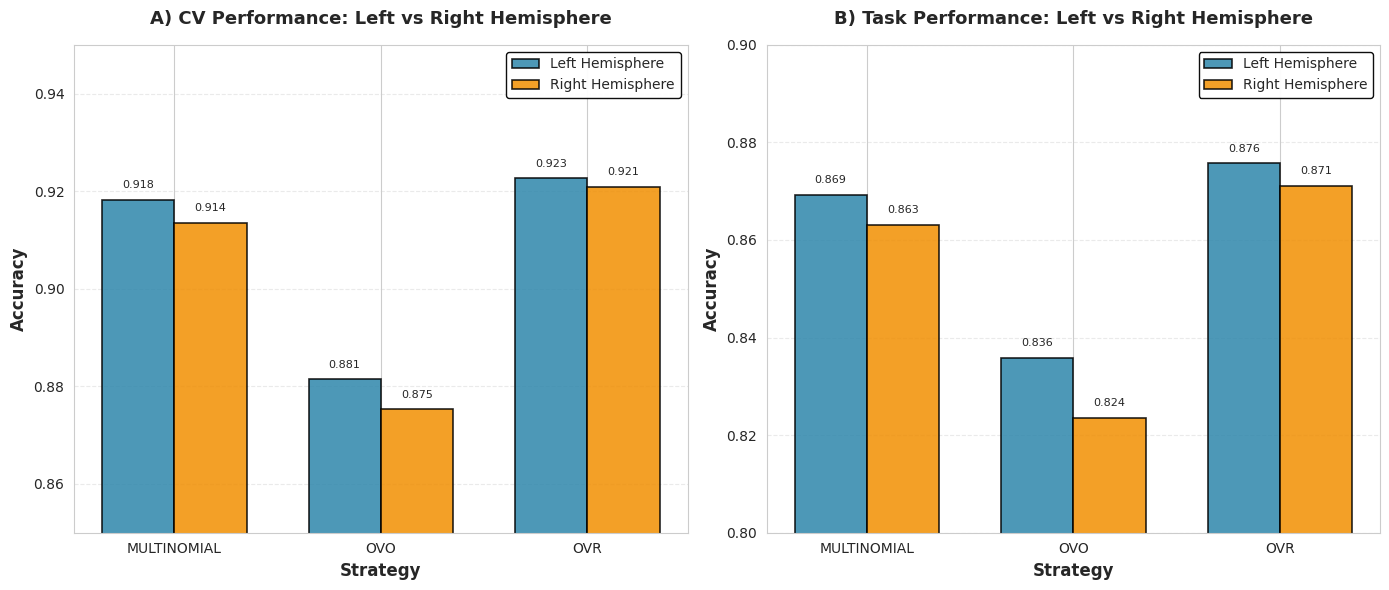

In [108]:
# Visualize hemisphere comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

strategies = ['MULTINOMIAL', 'OVO', 'OVR']
x = np.arange(len(strategies))
width = 0.35

# Plot 1: CV Accuracy
ax = axes[0]
left_cv_vals = [left_hemi[left_hemi['Strategy'] == s]['CV_Accuracy'].values[0] for s in strategies]
right_cv_vals = [right_hemi[right_hemi['Strategy'] == s]['CV_Accuracy'].values[0] for s in strategies]

bars1 = ax.bar(x - width/2, left_cv_vals, width, label='Left Hemisphere', 
               color='#2E86AB', edgecolor='black', linewidth=1.2, alpha=0.85)
bars2 = ax.bar(x + width/2, right_cv_vals, width, label='Right Hemisphere', 
               color='#F18F01', edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax.set_title('A) CV Performance: Left vs Right Hemisphere', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend(fontsize=10, framealpha=0.95, edgecolor='black')
ax.set_ylim([0.85, 0.95])
ax.grid(axis='y', alpha=0.4, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Plot 2: Task Accuracy
ax = axes[1]
left_task_vals = [left_hemi[left_hemi['Strategy'] == s]['Task_Accuracy'].values[0] for s in strategies]
right_task_vals = [right_hemi[right_hemi['Strategy'] == s]['Task_Accuracy'].values[0] for s in strategies]

bars1 = ax.bar(x - width/2, left_task_vals, width, label='Left Hemisphere', 
               color='#2E86AB', edgecolor='black', linewidth=1.2, alpha=0.85)
bars2 = ax.bar(x + width/2, right_task_vals, width, label='Right Hemisphere', 
               color='#F18F01', edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=12, fontweight='bold')
ax.set_title('B) Task Performance: Left vs Right Hemisphere', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend(fontsize=10, framealpha=0.95, edgecolor='black')
ax.set_ylim([0.80, 0.90])
ax.grid(axis='y', alpha=0.4, linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'hemisphere_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'hemisphere_comparison.pdf', bbox_inches='tight')
print("\n✓ Saved hemisphere comparison plot")
plt.show()

## 5. Network Analysis

In [86]:
# Network-level analysis
print("\n" + "="*80)
print("NETWORK-LEVEL ANALYSIS")
print("="*80)

# Filter for Full Connectivity, Multinomial, CV (most reliable)
network_cv = network_perf[(network_perf['Analysis'] == 'Full Connectivity') & 
                          (network_perf['Strategy'] == 'MULTINOMIAL') & 
                          (network_perf['Phase'] == 'CV')]

network_task = network_perf[(network_perf['Analysis'] == 'Full Connectivity') & 
                            (network_perf['Strategy'] == 'MULTINOMIAL') & 
                            (network_perf['Phase'] == 'Task')]

# Sort by accuracy
network_cv_sorted = network_cv.sort_values('accuracy', ascending=False)
network_task_sorted = network_task.sort_values('accuracy', ascending=False)

print("\n" + "-"*80)
print("TOP 10 NETWORKS (CV - Multinomial):")
print("-"*80)
print(network_cv_sorted.head(10)[['network', 'accuracy', 'n_regions']].to_string(index=False))

print("\n" + "-"*80)
print("BOTTOM 10 NETWORKS (CV - Multinomial):")
print("-"*80)
print(network_cv_sorted.tail(10)[['network', 'accuracy', 'n_regions']].to_string(index=False))

# Save rankings
network_cv_sorted[['network', 'accuracy', 'n_regions', 'n_samples']].to_csv(
    ANALYSIS_DIR / 'network_rankings_cv.csv', index=False
)
print(f"\n✓ Saved network rankings to: {ANALYSIS_DIR / 'network_rankings_cv.csv'}")


NETWORK-LEVEL ANALYSIS

--------------------------------------------------------------------------------
TOP 10 NETWORKS (CV - Multinomial):
--------------------------------------------------------------------------------
    network  accuracy  n_regions
      ContC  0.986607          6
    VisCent  0.970610         12
    VisPeri  0.967634         12
   DefaultC  0.962054          6
Putamen_ant  0.959821          2
    SomMotB  0.957738         15
    SomMotA  0.957472         19
Caudate_ant  0.955357          2
  DorsAttnB  0.942411         10
   DefaultA  0.939732         14

--------------------------------------------------------------------------------
BOTTOM 10 NETWORKS (CV - Multinomial):
--------------------------------------------------------------------------------
         network  accuracy  n_regions
  Accumbens_core  0.883929          2
    Amygdala_med  0.859375          2
 Accumbens_shell  0.841518          2
     Thalamus_VP  0.830357          2
Hippocampus_post  0.82

In [89]:
# import perasonr and spearmanr
from scipy.stats import pearsonr, spearmanr


# Analyze relationship between network size and performance
print("\n" + "="*80)
print("NETWORK SIZE vs PERFORMANCE")
print("="*80)

# Correlation analysis
corr_pearson, p_pearson = pearsonr(network_cv['n_regions'], network_cv['accuracy'])
corr_spearman, p_spearman = spearmanr(network_cv['n_regions'], network_cv['accuracy'])

print(f"\nPearson correlation:  r = {corr_pearson:.4f}, p = {p_pearson:.4e}")
print(f"Spearman correlation: ρ = {corr_spearman:.4f}, p = {p_spearman:.4e}")

if p_pearson < 0.05:
    direction = "positive" if corr_pearson > 0 else "negative"
    strength = "strong" if abs(corr_pearson) > 0.5 else "moderate" if abs(corr_pearson) > 0.3 else "weak"
    print(f"\n→ {strength.capitalize()} {direction} correlation detected")
    print(f"  Larger networks {'tend to be' if corr_pearson > 0 else 'tend NOT to be'} easier to classify")
else:
    print(f"\n→ No significant correlation")
    print(f"  Network size does not predict classification performance")

# Group by size
network_cv['size_category'] = pd.cut(network_cv['n_regions'], 
                                      bins=[0, 5, 10, 20], 
                                      labels=['Small (1-5)', 'Medium (6-10)', 'Large (11+)'])

print("\n" + "-"*80)
print("Performance by Network Size:")
print("-"*80)
size_performance = network_cv.groupby('size_category')['accuracy'].agg(['mean', 'std', 'count'])
print(size_performance)


NETWORK SIZE vs PERFORMANCE

Pearson correlation:  r = 0.4306, p = 1.2366e-02
Spearman correlation: ρ = 0.5823, p = 3.7826e-04

→ Moderate positive correlation detected
  Larger networks tend to be easier to classify

--------------------------------------------------------------------------------
Performance by Network Size:
--------------------------------------------------------------------------------
                   mean       std  count
size_category                           
Small (1-5)    0.830636  0.140968     16
Medium (6-10)  0.920950  0.054158      7
Large (11+)    0.946663  0.015080     10



✓ Saved network size analysis plot


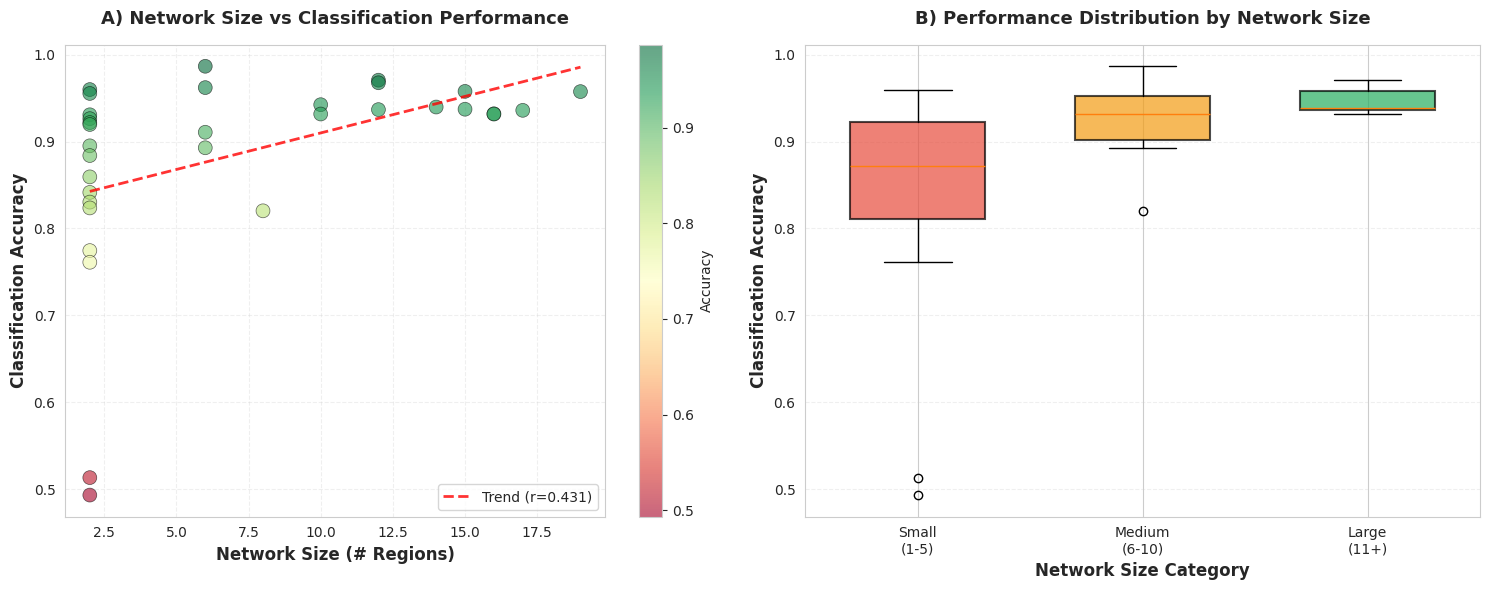

In [111]:
# Visualize network size vs performance
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter plot
ax = axes[0]
scatter = ax.scatter(network_cv['n_regions'], network_cv['accuracy'], 
                     s=100, alpha=0.6, c=network_cv['accuracy'], 
                     cmap='RdYlGn', edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(network_cv['n_regions'], network_cv['accuracy'], 1)
p = np.poly1d(z)
x_line = np.linspace(network_cv['n_regions'].min(), network_cv['n_regions'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, 
        label=f'Trend (r={corr_pearson:.3f})')

ax.set_xlabel('Network Size (# Regions)', fontsize=12, fontweight='bold')
ax.set_ylabel('Classification Accuracy', fontsize=12, fontweight='bold')
ax.set_title('A) Network Size vs Classification Performance', 
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Accuracy', fontsize=10)

# Plot 2: Box plot by size category
ax = axes[1]
size_data = [network_cv[network_cv['size_category'] == cat]['accuracy'].values 
             for cat in ['Small (1-5)', 'Medium (6-10)', 'Large (11+)']]

bp = ax.boxplot(size_data, labels=['Small\n(1-5)', 'Medium\n(6-10)', 'Large\n(11+)'],
                patch_artist=True, widths=0.6)

# Color the boxes
colors_box = ['#E74C3C', '#F39C12', '#27AE60']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax.set_xlabel('Network Size Category', fontsize=12, fontweight='bold')
ax.set_ylabel('Classification Accuracy', fontsize=12, fontweight='bold')
ax.set_title('B) Performance Distribution by Network Size', 
             fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'network_size_vs_performance.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'network_size_vs_performance.pdf', bbox_inches='tight')
print("\n✓ Saved network size analysis plot")
plt.show()

## 6. Region-Level Analysis

In [91]:
# Region-level analysis
print("\n" + "="*80)
print("REGION-LEVEL ANALYSIS")
print("="*80)

# Filter for Full Connectivity, Multinomial, CV
region_cv = region_perf[(region_perf['Analysis'] == 'Full Connectivity') & 
                        (region_perf['Strategy'] == 'MULTINOMIAL') & 
                        (region_perf['Phase'] == 'CV')]

region_task = region_perf[(region_perf['Analysis'] == 'Full Connectivity') & 
                          (region_perf['Strategy'] == 'MULTINOMIAL') & 
                          (region_perf['Phase'] == 'Task')]

# Sort by accuracy
region_cv_sorted = region_cv.sort_values('accuracy', ascending=False)
region_task_sorted = region_task.sort_values('accuracy', ascending=False)

print(f"\nTotal regions analyzed: {len(region_cv)}")

print("\n" + "-"*80)
print("TOP 20 MOST ACCURATELY CLASSIFIED REGIONS (CV):")
print("-"*80)
top_20_cv = region_cv_sorted.head(20)[['region_name', 'network', 'hemisphere', 'accuracy']]
print(top_20_cv.to_string(index=False))

print("\n" + "-"*80)
print("BOTTOM 20 REGIONS (Most Challenging to Classify - CV):")
print("-"*80)
bottom_20_cv = region_cv_sorted.tail(20)[['region_name', 'network', 'hemisphere', 'accuracy']]
print(bottom_20_cv.to_string(index=False))

# Save rankings
region_cv_sorted[['region_idx', 'region_name', 'network', 'hemisphere', 'accuracy']].to_csv(
    ANALYSIS_DIR / 'region_rankings_cv.csv', index=False
)
print(f"\n✓ Saved region rankings to: {ANALYSIS_DIR / 'region_rankings_cv.csv'}")


REGION-LEVEL ANALYSIS

Total regions analyzed: 232

--------------------------------------------------------------------------------
TOP 20 MOST ACCURATELY CLASSIFIED REGIONS (CV):
--------------------------------------------------------------------------------
            region_name      network hemisphere  accuracy
   LH_VisPeri_StriCal_1      VisPeri       left  1.000000
        LH_ContC_pCun_1        ContC       left  1.000000
  RH_DefaultA_pCunPCC_1     DefaultA      right  1.000000
  LH_VisPeri_ExStrSup_2      VisPeri       left  0.995536
   RH_VisPeri_StriCal_1      VisPeri      right  0.995536
      RH_DefaultC_Rsp_1     DefaultC      right  0.995536
   LH_VisCent_Striate_1      VisCent       left  0.995536
      LH_SomMotB_Cent_1      SomMotB       left  0.991071
      LH_DefaultC_Rsp_1     DefaultC       left  0.991071
   RH_VisCent_Striate_1      VisCent      right  0.991071
LH_SalVentAttnA_FrMed_1 SalVentAttnA       left  0.991071
        LH_SomMotB_S2_2      SomMotB     

In [110]:
# Calculate region-level reorganization (CV vs Task)
print("\n" + "="*80)
print("REGION-LEVEL REORGANIZATION ANALYSIS")
print("="*80)

# Merge CV and Task performance
region_reorganization = pd.merge(
    region_cv[['region_idx', 'region_name', 'network', 'hemisphere', 'accuracy']],
    region_task[['region_idx', 'accuracy']],
    on='region_idx',
    suffixes=('_cv', '_task')
)

region_reorganization['accuracy_drop'] = (
    region_reorganization['accuracy_cv'] - region_reorganization['accuracy_task']
)

region_reorganization = region_reorganization.sort_values('accuracy_drop', ascending=False)

print("\nOverall Region-Level Statistics:")
print(f"  Mean accuracy drop: {region_reorganization['accuracy_drop'].mean():.4f}")
print(f"  Std: {region_reorganization['accuracy_drop'].std():.4f}")
print(f"  Min (best generalization): {region_reorganization['accuracy_drop'].min():.4f}")
print(f"  Max (most reorganization): {region_reorganization['accuracy_drop'].max():.4f}")

print("\n" + "-"*80)
print("TOP 20 MOST REORGANIZED REGIONS (Largest Performance Drop):")
print("-"*80)
most_reorganized = region_reorganization.head(20)
print(most_reorganized[['region_name', 'network', 'accuracy_cv', 'accuracy_task', 'accuracy_drop']].to_string(index=False))

print("\n" + "-"*80)
print("TOP 20 MOST STABLE REGIONS (Smallest/Negative Drop):")
print("-"*80)
most_stable = region_reorganization.tail(20)
print(most_stable[['region_name', 'network', 'accuracy_cv', 'accuracy_task', 'accuracy_drop']].to_string(index=False))

# Save reorganization data
region_reorganization.to_csv(ANALYSIS_DIR / 'region_reorganization_analysis.csv', index=False)
print(f"\n✓ Saved region reorganization data")


REGION-LEVEL REORGANIZATION ANALYSIS

Overall Region-Level Statistics:
  Mean accuracy drop: 0.0317
  Std: 0.0550
  Min (best generalization): -0.0988
  Max (most reorganization): 0.2689

--------------------------------------------------------------------------------
TOP 20 MOST REORGANIZED REGIONS (Largest Performance Drop):
--------------------------------------------------------------------------------
          region_name          network  accuracy_cv  accuracy_task  accuracy_drop
               aGP-lh     Pallidum_ant     0.508929          0.240       0.268929
               aGP-rh     Pallidum_ant     0.517857          0.265       0.252857
RH_SalVentAttnA_PrC_1     SalVentAttnA     0.830357          0.585       0.245357
      RH_ContA_PFCl_1            ContA     0.937500          0.755       0.182500
            THA-VP-rh      Thalamus_VP     0.848214          0.680       0.168214
     LH_ContA_Cingm_1            ContA     0.919643          0.760       0.159643
              p


✓ Saved region performance comprehensive plot


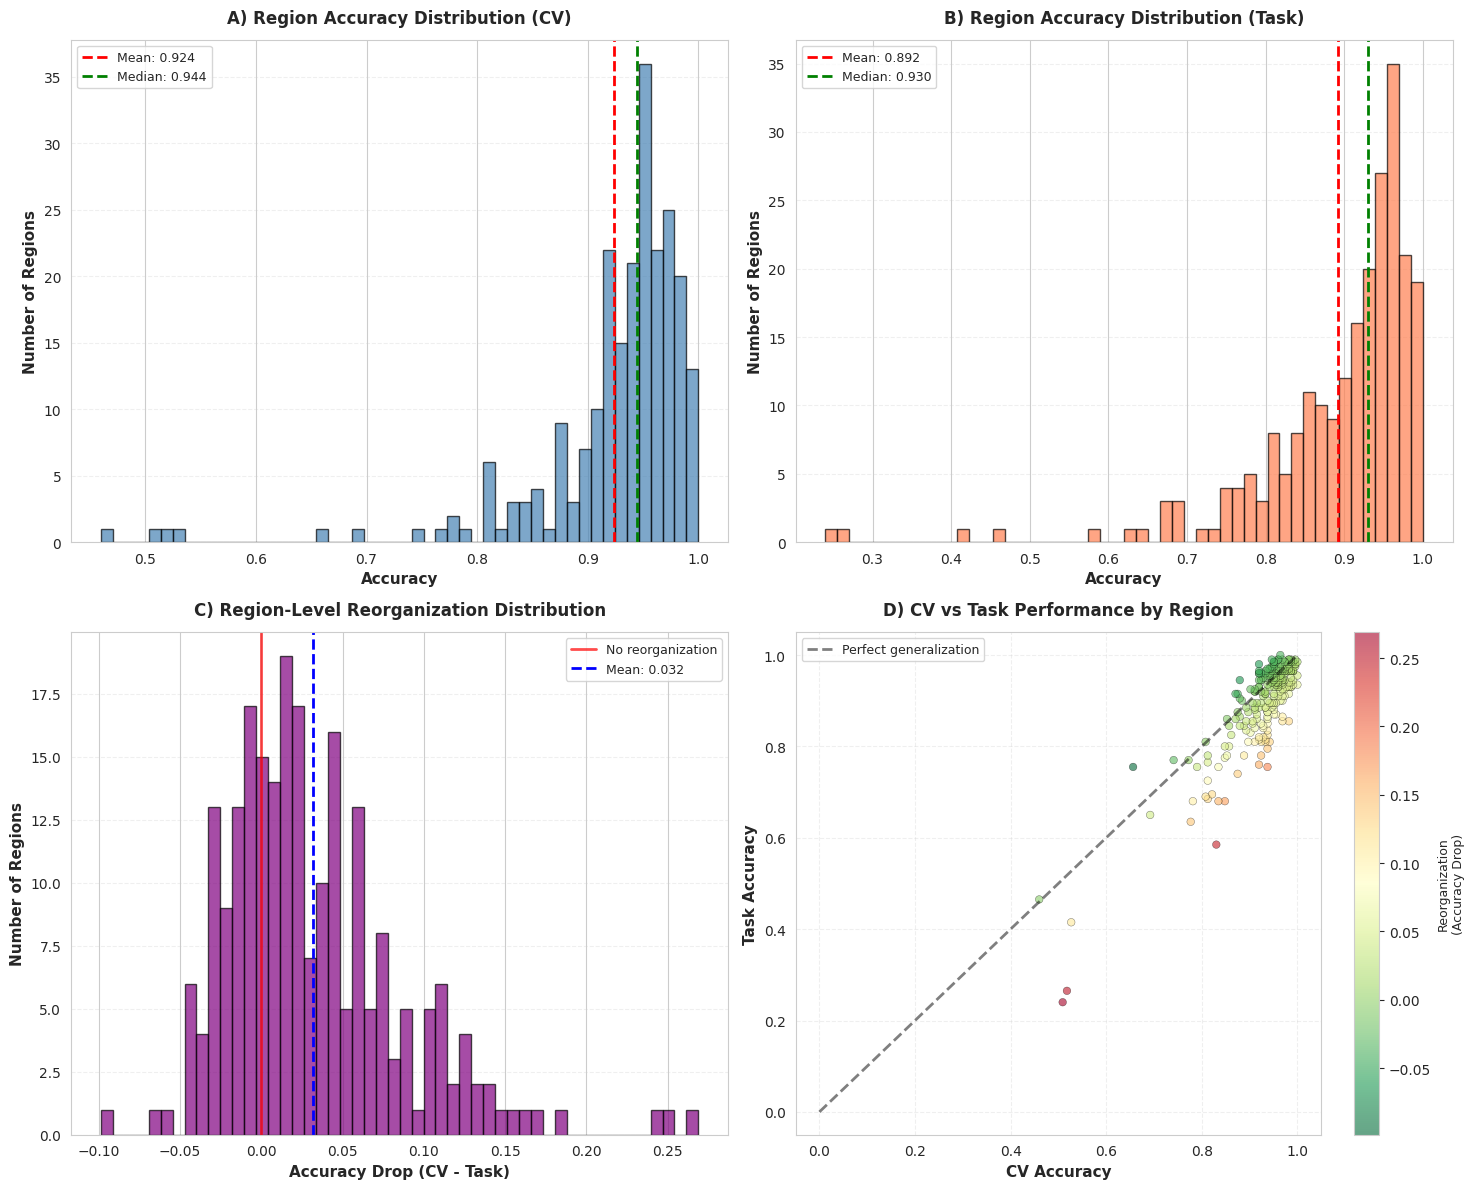

In [93]:
# Visualize region performance distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: CV Accuracy Distribution
ax = axes[0, 0]
ax.hist(region_cv['accuracy'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(region_cv['accuracy'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f"Mean: {region_cv['accuracy'].mean():.3f}")
ax.axvline(region_cv['accuracy'].median(), color='green', linestyle='--', linewidth=2, 
           label=f"Median: {region_cv['accuracy'].median():.3f}")
ax.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Regions', fontsize=11, fontweight='bold')
ax.set_title('A) Region Accuracy Distribution (CV)', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Task Accuracy Distribution
ax = axes[0, 1]
ax.hist(region_task['accuracy'], bins=50, edgecolor='black', alpha=0.7, color='coral')
ax.axvline(region_task['accuracy'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f"Mean: {region_task['accuracy'].mean():.3f}")
ax.axvline(region_task['accuracy'].median(), color='green', linestyle='--', linewidth=2, 
           label=f"Median: {region_task['accuracy'].median():.3f}")
ax.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Regions', fontsize=11, fontweight='bold')
ax.set_title('B) Region Accuracy Distribution (Task)', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 3: Reorganization Distribution
ax = axes[1, 0]
ax.hist(region_reorganization['accuracy_drop'], bins=50, edgecolor='black', 
        alpha=0.7, color='purple')
ax.axvline(0, color='red', linestyle='-', linewidth=2, alpha=0.7, label='No reorganization')
ax.axvline(region_reorganization['accuracy_drop'].mean(), color='blue', linestyle='--', 
           linewidth=2, label=f"Mean: {region_reorganization['accuracy_drop'].mean():.3f}")
ax.set_xlabel('Accuracy Drop (CV - Task)', fontsize=11, fontweight='bold')
ax.set_ylabel('Number of Regions', fontsize=11, fontweight='bold')
ax.set_title('C) Region-Level Reorganization Distribution', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 4: CV vs Task Scatter
ax = axes[1, 1]
scatter = ax.scatter(region_reorganization['accuracy_cv'], 
                     region_reorganization['accuracy_task'],
                     c=region_reorganization['accuracy_drop'], 
                     cmap='RdYlGn_r', alpha=0.6, s=30, 
                     edgecolors='black', linewidth=0.3)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5, label='Perfect generalization')
ax.set_xlabel('CV Accuracy', fontsize=11, fontweight='bold')
ax.set_ylabel('Task Accuracy', fontsize=11, fontweight='bold')
ax.set_title('D) CV vs Task Performance by Region', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Reorganization\n(Accuracy Drop)', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'region_performance_comprehensive.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'region_performance_comprehensive.pdf', bbox_inches='tight')
print("\n✓ Saved region performance comprehensive plot")
plt.show()

In [94]:
# Analyze region performance by network
print("\n" + "="*80)
print("REGION PERFORMANCE BY NETWORK")
print("="*80)

region_by_network = region_cv.groupby('network')['accuracy'].agg(['mean', 'std', 'min', 'max', 'count'])
region_by_network = region_by_network.sort_values('mean', ascending=False)

print("\nRegion Performance Statistics by Network:")
print(region_by_network.round(4))

# Which networks have most variable region performance?
print("\n" + "-"*80)
print("Networks with MOST variable region performance (highest std):")
print("-"*80)
most_variable = region_by_network.nlargest(10, 'std')
print(most_variable[['mean', 'std', 'count']])

print("\n" + "-"*80)
print("Networks with LEAST variable region performance (lowest std):")
print("-"*80)
least_variable = region_by_network.nsmallest(10, 'std')
print(least_variable[['mean', 'std', 'count']])


REGION PERFORMANCE BY NETWORK

Region Performance Statistics by Network:
                    mean     std     min     max  count
network                                                
ContC             0.9866  0.0089  0.9732  1.0000      6
VisCent           0.9706  0.0231  0.9286  0.9955     12
VisPeri           0.9676  0.0401  0.8482  1.0000     12
DefaultC          0.9621  0.0254  0.9330  0.9955      6
Putamen_ant       0.9598  0.0126  0.9509  0.9688      2
SomMotB           0.9577  0.0222  0.9241  0.9911     15
SomMotA           0.9575  0.0153  0.9286  0.9821     19
Caudate_ant       0.9554  0.0063  0.9509  0.9598      2
DorsAttnB         0.9424  0.0267  0.8973  0.9732     10
DefaultA          0.9397  0.0863  0.6562  1.0000     14
ContB             0.9372  0.0190  0.9107  0.9643     15
DorsAttnA         0.9368  0.0280  0.8795  0.9598     12
DefaultB          0.9359  0.0380  0.8527  0.9866     17
ContA             0.9319  0.0287  0.8705  0.9732     16
SalVentAttnB      0.9317  0.02

## 7. Generalization Error

In [95]:
# Network-level generalization analysis
print("\n" + "="*80)
print("GENERALIZATION ANALYSIS: NETWORK LEVEL")
print("="*80)
print("(Error-as-Signal Framework - Core Thesis Contribution)")
print("="*80)

# Merge CV and Task network performance
network_generalization = pd.merge(
    network_cv[['network', 'accuracy', 'n_regions']],
    network_task[['network', 'accuracy']],
    on='network',
    suffixes=('_cv', '_task')
)

network_generalization['accuracy_drop'] = (
    network_generalization['accuracy_cv'] - network_generalization['accuracy_task']
)

network_generalization = network_generalization.sort_values('accuracy_drop', ascending=False)

print("\nNetwork-Level Generalization Statistics:")
print(f"  Mean drop: {network_generalization['accuracy_drop'].mean():.4f}")
print(f"  Std: {network_generalization['accuracy_drop'].std():.4f}")
print(f"  Min: {network_generalization['accuracy_drop'].min():.4f}")
print(f"  Max: {network_generalization['accuracy_drop'].max():.4f}")

print("\n" + "-"*80)
print("TOP 10 NETWORKS WITH MOST REORGANIZATION:")
print("-"*80)
print(network_generalization.head(10)[['network', 'accuracy_cv', 'accuracy_task', 'accuracy_drop', 'n_regions']].to_string(index=False))

print("\n" + "-"*80)
print("TOP 10 NETWORKS WITH BEST GENERALIZATION (Most Stable):")
print("-"*80)
print(network_generalization.tail(10)[['network', 'accuracy_cv', 'accuracy_task', 'accuracy_drop', 'n_regions']].to_string(index=False))

# Save
network_generalization.to_csv(ANALYSIS_DIR / 'network_generalization_analysis.csv', index=False)
print(f"\n✓ Saved network generalization analysis")


GENERALIZATION ANALYSIS: NETWORK LEVEL
(Error-as-Signal Framework - Core Thesis Contribution)

Network-Level Generalization Statistics:
  Mean drop: 0.0548
  Std: 0.0545
  Min: -0.0058
  Max: 0.2609

--------------------------------------------------------------------------------
TOP 10 NETWORKS WITH MOST REORGANIZATION:
--------------------------------------------------------------------------------
         network  accuracy_cv  accuracy_task  accuracy_drop  n_regions
    Pallidum_ant     0.513393       0.252500       0.260893          2
Hippocampus_post     0.823661       0.682500       0.141161          2
     Thalamus_VP     0.830357       0.702500       0.127857          2
 Accumbens_shell     0.841518       0.715000       0.126518          2
    Putamen_post     0.921875       0.797500       0.124375          2
     Thalamus_VA     0.926339       0.835000       0.091339          2
 Hippocampus_ant     0.919643       0.840000       0.079643          2
    Amygdala_lat     0.7745

In [96]:
# Does high CV performance predict more reorganization?
print("\n" + "="*80)
print("CV PERFORMANCE vs REORGANIZATION")
print("="*80)

corr_cv_drop, p_cv_drop = pearsonr(network_generalization['accuracy_cv'], 
                                     network_generalization['accuracy_drop'])

print(f"\nCorrelation between CV accuracy and performance drop:")
print(f"  Pearson r = {corr_cv_drop:.4f}, p = {p_cv_drop:.4e}")

if p_cv_drop < 0.05:
    if corr_cv_drop > 0:
        print(f"\n→ Significant POSITIVE correlation")
        print(f"  Networks with higher CV accuracy show MORE reorganization")
        print(f"  (These networks may rely more on resting-state patterns)")
    else:
        print(f"\n→ Significant NEGATIVE correlation")
        print(f"  Networks with higher CV accuracy show LESS reorganization")
        print(f"  (These networks have more stable connectivity patterns)")
else:
    print(f"\n→ No significant correlation")
    print(f"  CV performance does not predict reorganization")

# Correlation: Network size vs reorganization
corr_size_drop, p_size_drop = pearsonr(network_generalization['n_regions'], 
                                        network_generalization['accuracy_drop'])

print(f"\n" + "-"*80)
print(f"Correlation between network size and reorganization:")
print(f"  Pearson r = {corr_size_drop:.4f}, p = {p_size_drop:.4e}")

if p_size_drop < 0.05:
    direction = "larger" if corr_size_drop > 0 else "smaller"
    print(f"\n→ {direction.capitalize()} networks show more reorganization")
else:
    print(f"\n→ Network size does not predict reorganization")


CV PERFORMANCE vs REORGANIZATION

Correlation between CV accuracy and performance drop:
  Pearson r = -0.5693, p = 5.4460e-04

→ Significant NEGATIVE correlation
  Networks with higher CV accuracy show LESS reorganization
  (These networks have more stable connectivity patterns)

--------------------------------------------------------------------------------
Correlation between network size and reorganization:
  Pearson r = -0.5290, p = 1.5479e-03

→ Smaller networks show more reorganization



✓ Saved generalization analysis comprehensive plot


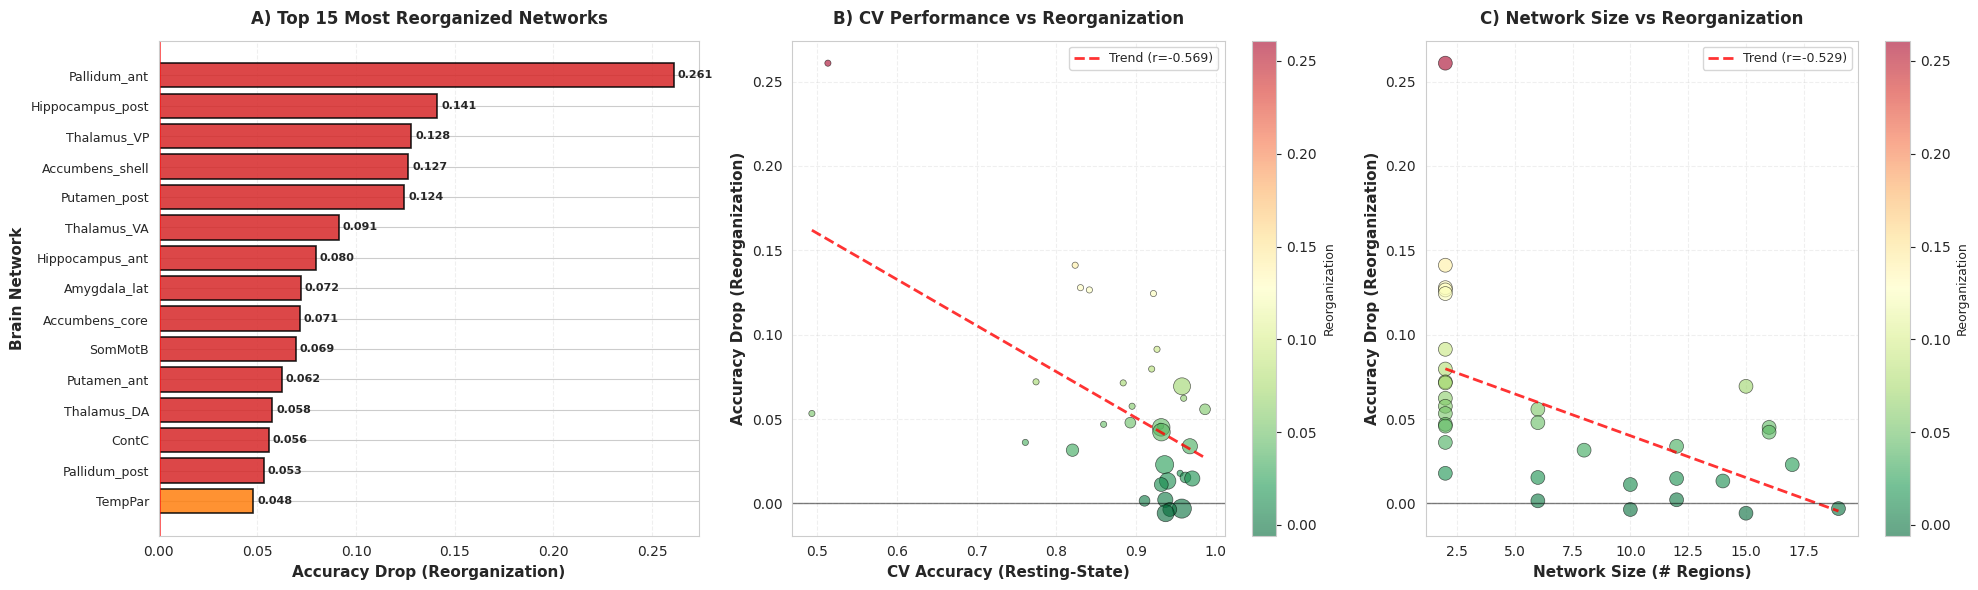

In [97]:
# Visualize generalization analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Network Generalization Ranking
ax = axes[0]
top_reorg = network_generalization.head(15).sort_values('accuracy_drop', ascending=True)
colors_reorg = ['#d62728' if x > 0.05 else '#ff7f0e' if x > 0.03 else '#2ca02c' 
                for x in top_reorg['accuracy_drop']]

bars = ax.barh(range(len(top_reorg)), top_reorg['accuracy_drop'], 
               color=colors_reorg, edgecolor='black', linewidth=1.2, alpha=0.85)
ax.set_yticks(range(len(top_reorg)))
ax.set_yticklabels(top_reorg['network'], fontsize=9)
ax.set_xlabel('Accuracy Drop (Reorganization)', fontsize=11, fontweight='bold')
ax.set_ylabel('Brain Network', fontsize=11, fontweight='bold')
ax.set_title('A) Top 15 Most Reorganized Networks', fontsize=12, fontweight='bold', pad=12)
ax.axvline(x=0, color='red', linestyle='-', linewidth=2, alpha=0.7)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_reorg['accuracy_drop'])):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{val:.3f}', va='center', fontsize=8, fontweight='bold')

# Plot 2: CV Accuracy vs Reorganization
ax = axes[1]
scatter = ax.scatter(network_generalization['accuracy_cv'], 
                     network_generalization['accuracy_drop'],
                     s=network_generalization['n_regions']*10, 
                     alpha=0.6, c=network_generalization['accuracy_drop'], 
                     cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(network_generalization['accuracy_cv'], 
               network_generalization['accuracy_drop'], 1)
p = np.poly1d(z)
x_line = np.linspace(network_generalization['accuracy_cv'].min(), 
                     network_generalization['accuracy_cv'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, 
        label=f'Trend (r={corr_cv_drop:.3f})')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('CV Accuracy (Resting-State)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy Drop (Reorganization)', fontsize=11, fontweight='bold')
ax.set_title('B) CV Performance vs Reorganization', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Reorganization', fontsize=9)

# Plot 3: Network Size vs Reorganization
ax = axes[2]
scatter = ax.scatter(network_generalization['n_regions'], 
                     network_generalization['accuracy_drop'],
                     s=100, alpha=0.6, 
                     c=network_generalization['accuracy_drop'], 
                     cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)

# Add trend line
z = np.polyfit(network_generalization['n_regions'], 
               network_generalization['accuracy_drop'], 1)
p = np.poly1d(z)
x_line = np.linspace(network_generalization['n_regions'].min(), 
                     network_generalization['n_regions'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, alpha=0.8, 
        label=f'Trend (r={corr_size_drop:.3f})')

ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_xlabel('Network Size (# Regions)', fontsize=11, fontweight='bold')
ax.set_ylabel('Accuracy Drop (Reorganization)', fontsize=11, fontweight='bold')
ax.set_title('C) Network Size vs Reorganization', fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Reorganization', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'generalization_analysis_comprehensive.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'generalization_analysis_comprehensive.pdf', bbox_inches='tight')
print("\n✓ Saved generalization analysis comprehensive plot")
plt.show()

## 8. Top K accuracy Analysis

In [98]:
# Top-K accuracy analysis
print("\n" + "="*80)
print("TOP-K ACCURACY ANALYSIS")
print("="*80)
print("(Understanding Model Confidence)")
print("="*80)

# Compare Top-1 vs Top-5 accuracy
print("\nTop-1 vs Top-5 Accuracy:")
print("-"*80)

for idx, row in summary_df.iterrows():
    top1_cv = row['CV_Accuracy']
    top5_cv = row['Top_5_CV']
    top1_task = row['Task_Accuracy']
    top5_task = row['Top_5_Task']
    
    improvement_cv = (top5_cv - top1_cv) * 100
    improvement_task = (top5_task - top1_task) * 100
    
    print(f"\n{row['Analysis']} - {row['Strategy']}:")
    print(f"  CV:   Top-1={top1_cv:.4f}, Top-5={top5_cv:.4f}, Improvement=+{improvement_cv:.2f}%")
    print(f"  Task: Top-1={top1_task:.4f}, Top-5={top5_task:.4f}, Improvement=+{improvement_task:.2f}%")

# Overall statistics
print("\n" + "-"*80)
print("OVERALL TOP-K STATISTICS:")
print("-"*80)

avg_top1_cv = summary_df['CV_Accuracy'].mean()
avg_top5_cv = summary_df['Top_5_CV'].mean()
avg_top1_task = summary_df['Task_Accuracy'].mean()
avg_top5_task = summary_df['Top_5_Task'].mean()

print(f"\nCV (Average across all conditions):")
print(f"  Top-1: {avg_top1_cv:.4f}")
print(f"  Top-5: {avg_top5_cv:.4f}")
print(f"  Improvement: +{(avg_top5_cv - avg_top1_cv)*100:.2f}%")

print(f"\nTask (Average across all conditions):")
print(f"  Top-1: {avg_top1_task:.4f}")
print(f"  Top-5: {avg_top5_task:.4f}")
print(f"  Improvement: +{(avg_top5_task - avg_top1_task)*100:.2f}%")

print("\n→ Key Insight:")
if (avg_top5_cv - avg_top1_cv) > 0.05:
    print("  Even when exact predictions fail, the true network is frequently")
    print("  in the top-5 predictions, indicating good model confidence.")


TOP-K ACCURACY ANALYSIS
(Understanding Model Confidence)

Top-1 vs Top-5 Accuracy:
--------------------------------------------------------------------------------

Full Connectivity - MULTINOMIAL:
  CV:   Top-1=0.9241, Top-5=0.9833, Improvement=+5.92%
  Task: Top-1=0.8924, Top-5=0.9726, Improvement=+8.02%

Full Connectivity - OVO:
  CV:   Top-1=0.8688, Top-5=0.9616, Improvement=+9.28%
  Task: Top-1=0.8305, Top-5=0.0000, Improvement=+-83.05%

Full Connectivity - OVR:
  CV:   Top-1=0.9317, Top-5=0.9837, Improvement=+5.20%
  Task: Top-1=0.8963, Top-5=0.9707, Improvement=+7.44%

Left Hemisphere - MULTINOMIAL:
  CV:   Top-1=0.9182, Top-5=0.9827, Improvement=+6.45%
  Task: Top-1=0.8693, Top-5=0.9704, Improvement=+10.11%

Left Hemisphere - OVO:
  CV:   Top-1=0.8814, Top-5=0.9703, Improvement=+8.88%
  Task: Top-1=0.8359, Top-5=0.9541, Improvement=+11.83%

Left Hemisphere - OVR:
  CV:   Top-1=0.9226, Top-5=0.9837, Improvement=+6.11%
  Task: Top-1=0.8757, Top-5=0.9691, Improvement=+9.34%

Righ


✓ Saved Top-K accuracy comparison plot


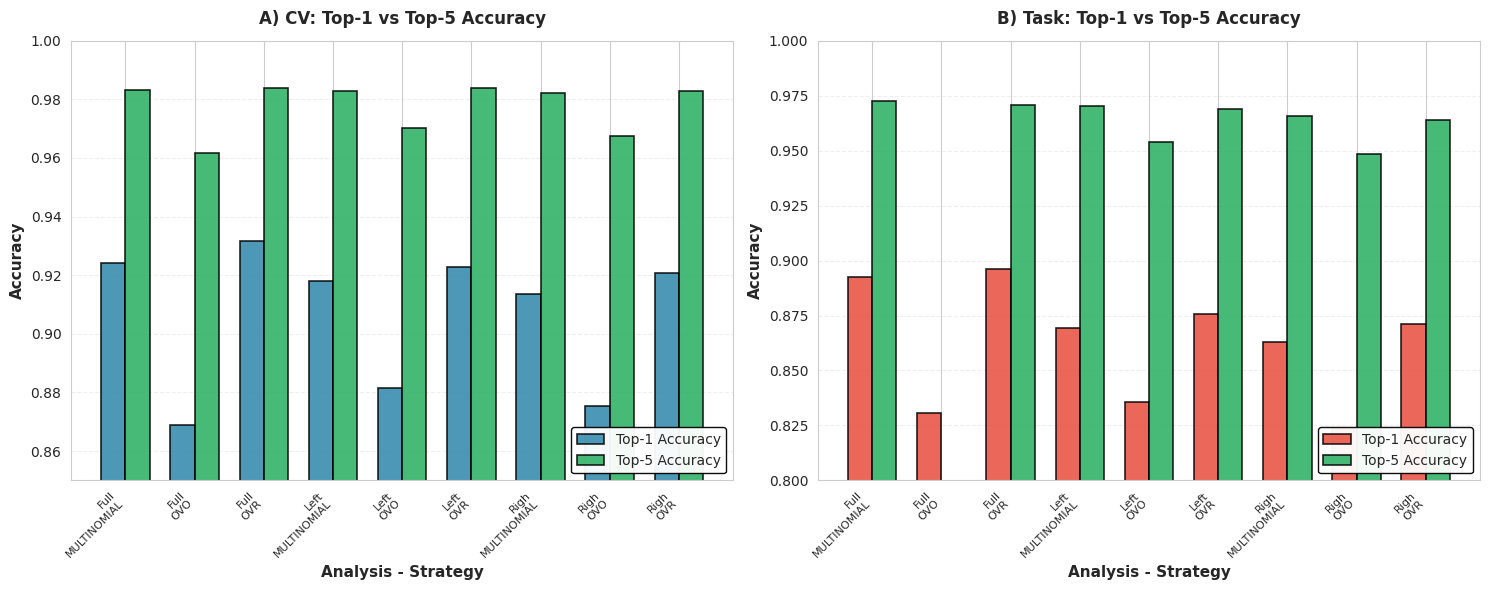

In [99]:
# Visualize Top-K accuracy
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Prepare data
conditions = [f"{row['Analysis'][:4]}\n{row['Strategy']}" 
              for _, row in summary_df.iterrows()]
top1_cv = summary_df['CV_Accuracy'].values
top5_cv = summary_df['Top_5_CV'].values
top1_task = summary_df['Task_Accuracy'].values
top5_task = summary_df['Top_5_Task'].values

x = np.arange(len(conditions))
width = 0.35

# Plot 1: CV - Top-1 vs Top-5
ax = axes[0]
bars1 = ax.bar(x - width/2, top1_cv, width, label='Top-1 Accuracy', 
               color='#2E86AB', edgecolor='black', linewidth=1.2, alpha=0.85)
bars2 = ax.bar(x + width/2, top5_cv, width, label='Top-5 Accuracy', 
               color='#27AE60', edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_xlabel('Analysis - Strategy', fontsize=11, fontweight='bold')
ax.set_title('A) CV: Top-1 vs Top-5 Accuracy', fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=8, rotation=45, ha='right')
ax.legend(fontsize=10, loc='lower right', framealpha=0.95, edgecolor='black')
ax.set_ylim([0.85, 1.00])
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Plot 2: Task - Top-1 vs Top-5
ax = axes[1]
bars1 = ax.bar(x - width/2, top1_task, width, label='Top-1 Accuracy', 
               color='#E74C3C', edgecolor='black', linewidth=1.2, alpha=0.85)
bars2 = ax.bar(x + width/2, top5_task, width, label='Top-5 Accuracy', 
               color='#27AE60', edgecolor='black', linewidth=1.2, alpha=0.85)

ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax.set_xlabel('Analysis - Strategy', fontsize=11, fontweight='bold')
ax.set_title('B) Task: Top-1 vs Top-5 Accuracy', fontsize=12, fontweight='bold', pad=12)
ax.set_xticks(x)
ax.set_xticklabels(conditions, fontsize=8, rotation=45, ha='right')
ax.legend(fontsize=10, loc='lower right', framealpha=0.95, edgecolor='black')
ax.set_ylim([0.80, 1.00])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'topk_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'topk_accuracy_comparison.pdf', bbox_inches='tight')
print("\n✓ Saved Top-K accuracy comparison plot")
plt.show()

## 9. Performance Variability

In [100]:
# Performance variability analysis
print("\n" + "="*80)
print("PERFORMANCE VARIABILITY ANALYSIS")
print("="*80)
print("(Strategy Stability Across Folds)")
print("="*80)

# Analyze CV standard deviations
print("\nCross-Validation Stability (Lower std = more stable):")
print("-"*80)

stability_df = cv_perf[['Analysis', 'Strategy', 'Accuracy', 'Accuracy_Std']].copy()
stability_df = stability_df.sort_values('Accuracy_Std')

print(stability_df.to_string(index=False))

# Find most/least stable
print("\n" + "-"*80)
print("MOST STABLE (Lowest Std):")
print("-"*80)
most_stable_config = stability_df.iloc[0]
print(f"  {most_stable_config['Analysis']} - {most_stable_config['Strategy']}")
print(f"  Accuracy: {most_stable_config['Accuracy']:.4f} ± {most_stable_config['Accuracy_Std']:.4f}")
print(f"  → Coefficient of Variation: {(most_stable_config['Accuracy_Std']/most_stable_config['Accuracy'])*100:.2f}%")

print("\n" + "-"*80)
print("LEAST STABLE (Highest Std):")
print("-"*80)
least_stable_config = stability_df.iloc[-1]
print(f"  {least_stable_config['Analysis']} - {least_stable_config['Strategy']}")
print(f"  Accuracy: {least_stable_config['Accuracy']:.4f} ± {least_stable_config['Accuracy_Std']:.4f}")
print(f"  → Coefficient of Variation: {(least_stable_config['Accuracy_Std']/least_stable_config['Accuracy'])*100:.2f}%")

# Strategy comparison
print("\n" + "-"*80)
print("STABILITY BY STRATEGY (Average across analyses):")
print("-"*80)
strategy_stability = cv_perf.groupby('Strategy')['Accuracy_Std'].mean().sort_values()
for strategy, std in strategy_stability.items():
    print(f"  {strategy}: {std:.6f}")


PERFORMANCE VARIABILITY ANALYSIS
(Strategy Stability Across Folds)

Cross-Validation Stability (Lower std = more stable):
--------------------------------------------------------------------------------
         Analysis    Strategy  Accuracy  Accuracy_Std
Full Connectivity         OVR  0.931708      0.001876
 Right Hemisphere MULTINOMIAL  0.913562      0.002358
Full Connectivity MULTINOMIAL  0.924126      0.002439
 Right Hemisphere         OVR  0.920836      0.002929
Full Connectivity         OVO  0.868785      0.003630
 Right Hemisphere         OVO  0.875269      0.004479
  Left Hemisphere MULTINOMIAL  0.918180      0.004778
  Left Hemisphere         OVR  0.922645      0.004891
  Left Hemisphere         OVO  0.881427      0.007082

--------------------------------------------------------------------------------
MOST STABLE (Lowest Std):
--------------------------------------------------------------------------------
  Full Connectivity - OVR
  Accuracy: 0.9317 ± 0.0019
  → Coefficie


✓ Saved performance variability analysis plot


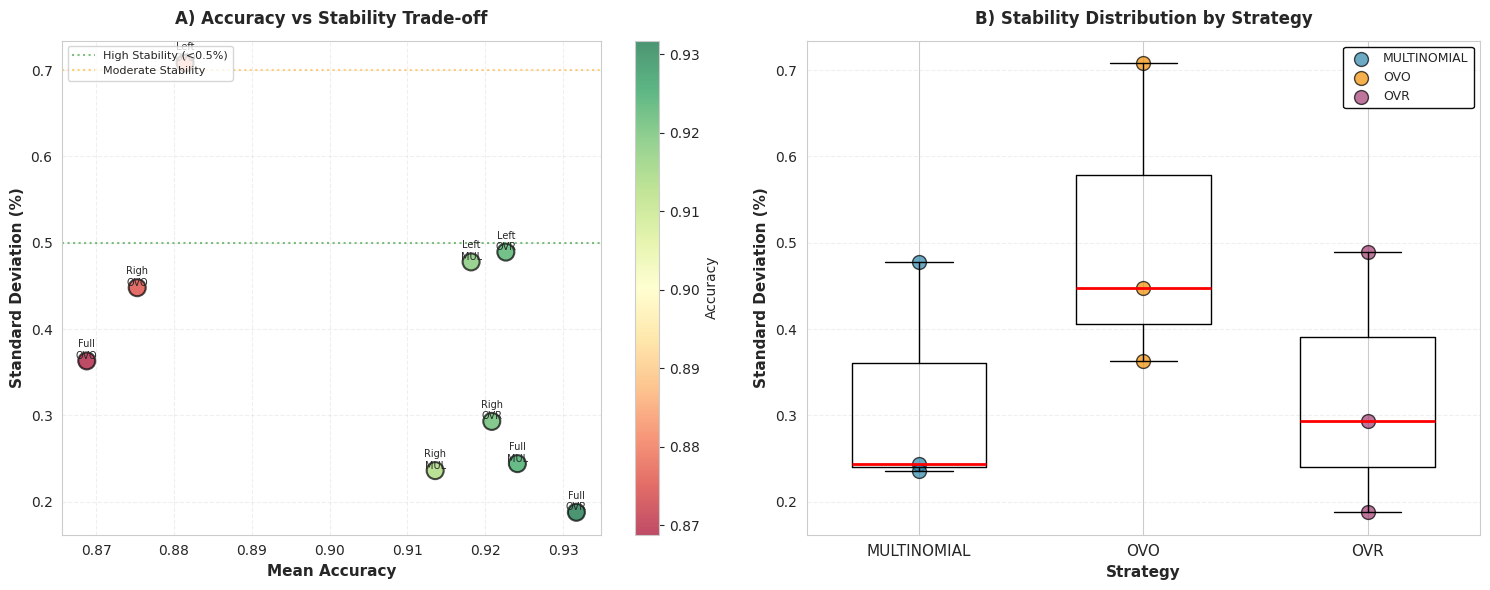

In [101]:
# Visualize performance variability
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Accuracy vs Stability
ax = axes[0]
scatter = ax.scatter(cv_perf['Accuracy'], cv_perf['Accuracy_Std']*100,  # Convert to percentage
                     s=150, alpha=0.7, c=cv_perf['Accuracy'], 
                     cmap='RdYlGn', edgecolors='black', linewidth=1.5)

# Add labels for each point
for idx, row in cv_perf.iterrows():
    ax.annotate(f"{row['Analysis'][:4]}\n{row['Strategy'][:3]}", 
                (row['Accuracy'], row['Accuracy_Std']*100),
                fontsize=7, ha='center', va='bottom')

ax.set_xlabel('Mean Accuracy', fontsize=11, fontweight='bold')
ax.set_ylabel('Standard Deviation (%)', fontsize=11, fontweight='bold')
ax.set_title('A) Accuracy vs Stability Trade-off', fontsize=12, fontweight='bold', pad=12)
ax.grid(alpha=0.3, linestyle='--')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Accuracy', fontsize=10)

# Add interpretation zones
ax.axhline(y=0.5, color='green', linestyle=':', linewidth=1.5, alpha=0.5, 
           label='High Stability (<0.5%)')
ax.axhline(y=0.7, color='orange', linestyle=':', linewidth=1.5, alpha=0.5, 
           label='Moderate Stability')
ax.legend(fontsize=8, loc='upper left')

# Plot 2: Stability by Strategy
ax = axes[1]
strategies = cv_perf['Strategy'].unique()
colors = ['#2E86AB', '#F18F01', '#A23B72']

for i, strategy in enumerate(strategies):
    strategy_data = cv_perf[cv_perf['Strategy'] == strategy]
    x_pos = [i] * len(strategy_data)
    ax.scatter(x_pos, strategy_data['Accuracy_Std']*100, 
               s=100, alpha=0.7, color=colors[i], 
               edgecolors='black', linewidth=1, label=strategy)

# Add box plot overlay
strategy_stds = [cv_perf[cv_perf['Strategy'] == s]['Accuracy_Std'].values * 100 
                 for s in strategies]
bp = ax.boxplot(strategy_stds, positions=range(len(strategies)), 
                widths=0.6, patch_artist=False, 
                showfliers=False, medianprops=dict(color='red', linewidth=2))

ax.set_xticks(range(len(strategies)))
ax.set_xticklabels(strategies, fontsize=11)
ax.set_ylabel('Standard Deviation (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=11, fontweight='bold')
ax.set_title('B) Stability Distribution by Strategy', fontsize=12, fontweight='bold', pad=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(fontsize=9, loc='upper right', framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'performance_variability_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'performance_variability_analysis.pdf', bbox_inches='tight')
print("\n✓ Saved performance variability analysis plot")
plt.show()

## 10. Final Sumamry

In [102]:
# Generate comprehensive summary report
print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80)

summary_report = {
    'overall_performance': {
        'best_cv_configuration': {
            'analysis': best_cv['Analysis'],
            'strategy': best_cv['Strategy'],
            'accuracy': float(best_cv['CV_Accuracy']),
            'std': float(best_cv['CV_Std'])
        },
        'best_task_configuration': {
            'analysis': best_task['Analysis'],
            'strategy': best_task['Strategy'],
            'accuracy': float(best_task['Task_Accuracy'])
        },
        'best_generalization': {
            'analysis': best_gen['Analysis'],
            'strategy': best_gen['Strategy'],
            'drop': float(best_gen['Drop'])
        }
    },
    'strategy_analysis': {
        'ranking_by_cv_accuracy': {
            strategy: float(acc) for strategy, acc in cv_rank.items()
        },
        'ranking_by_task_accuracy': {
            strategy: float(acc) for strategy, acc in task_rank.items()
        },
        'stability_ranking': {
            strategy: float(std) for strategy, std in strategy_stability.items()
        }
    },
    'hemisphere_analysis': {
        'left_cv_mean': float(left_hemi['CV_Accuracy'].mean()),
        'right_cv_mean': float(right_hemi['CV_Accuracy'].mean()),
        'difference': float(cv_diff),
        'interpretation': 'Minimal lateralization effect' if abs(cv_diff) < 0.01 else 'Lateralization detected'
    },
    'network_analysis': {
        'total_networks': int(network_cv['network'].nunique()),
        'best_network': network_cv_sorted.iloc[0]['network'],
        'best_network_accuracy': float(network_cv_sorted.iloc[0]['accuracy']),
        'worst_network': network_cv_sorted.iloc[-1]['network'],
        'worst_network_accuracy': float(network_cv_sorted.iloc[-1]['accuracy']),
        'size_correlation': {
            'pearson_r': float(corr_pearson),
            'p_value': float(p_pearson),
            'interpretation': 'Significant' if p_pearson < 0.05 else 'Not significant'
        }
    },
    'region_analysis': {
        'total_regions': int(len(region_cv)),
        'mean_cv_accuracy': float(region_cv['accuracy'].mean()),
        'mean_task_accuracy': float(region_task['accuracy'].mean()),
        'mean_reorganization': float(region_reorganization['accuracy_drop'].mean()),
        'regions_with_improvement': int((region_reorganization['accuracy_drop'] < 0).sum())
    },
    'generalization_analysis': {
        'mean_network_drop': float(network_generalization['accuracy_drop'].mean()),
        'most_reorganized_network': network_generalization.iloc[0]['network'],
        'most_reorganized_drop': float(network_generalization.iloc[0]['accuracy_drop']),
        'cv_performance_reorganization_correlation': {
            'pearson_r': float(corr_cv_drop),
            'p_value': float(p_cv_drop),
            'interpretation': 'High CV accuracy predicts more reorganization' if corr_cv_drop > 0 and p_cv_drop < 0.05 
                            else 'High CV accuracy predicts less reorganization' if corr_cv_drop < 0 and p_cv_drop < 0.05
                            else 'No significant relationship'
        }
    },
    'topk_analysis': {
        'cv_top1_mean': float(avg_top1_cv),
        'cv_top5_mean': float(avg_top5_cv),
        'cv_improvement': float((avg_top5_cv - avg_top1_cv) * 100),
        'task_top1_mean': float(avg_top1_task),
        'task_top5_mean': float(avg_top5_task),
        'task_improvement': float((avg_top5_task - avg_top1_task) * 100)
    }
}

# Save summary report
with open(ANALYSIS_DIR / 'performance_analysis_summary_report.json', 'w') as f:
    json.dump(summary_report, f, indent=2)

print("\n✓ Comprehensive summary report saved!")
print(f"   Location: {ANALYSIS_DIR / 'performance_analysis_summary_report.json'}")

# Print key findings
print("\n" + "="*80)
print("KEY FINDINGS")
print("="*80)

print("\n1. BEST CONFIGURATION:")
print(f"   CV: {best_cv['Analysis']} - {best_cv['Strategy']} ({best_cv['CV_Accuracy']:.4f})")
print(f"   Task: {best_task['Analysis']} - {best_task['Strategy']} ({best_task['Task_Accuracy']:.4f})")

print("\n2. STRATEGY RECOMMENDATION:")
print(f"   Highest CV Accuracy: {list(cv_rank.keys())[0]}")
print(f"   Highest Task Accuracy: {list(task_rank.keys())[0]}")
print(f"   Most Stable: {list(strategy_stability.keys())[0]}")

print("\n3. HEMISPHERE EFFECTS:")
if abs(cv_diff) < 0.01:
    print(f"   Minimal difference between hemispheres (<1%)")
else:
    better_hemi = 'Left' if cv_diff > 0 else 'Right'
    print(f"   {better_hemi} hemisphere shows better performance")

print("\n4. REORGANIZATION (Error-as-Signal):")
print(f"   Mean performance drop: {network_generalization['accuracy_drop'].mean():.4f}")
print(f"   Most reorganized network: {network_generalization.iloc[0]['network']}")
print(f"   Networks with improvement: {(network_generalization['accuracy_drop'] < 0).sum()}")

print("\n5. TOP-K ACCURACY:")
print(f"   CV Top-5 improvement: +{(avg_top5_cv - avg_top1_cv)*100:.2f}%")
print(f"   Task Top-5 improvement: +{(avg_top5_task - avg_top1_task)*100:.2f}%")


FINAL SUMMARY REPORT

✓ Comprehensive summary report saved!
   Location: /home/sjoon/projects/brain_connectivity_classifier/data/analysis/performance_analysis_summary_report.json

KEY FINDINGS

1. BEST CONFIGURATION:
   CV: Full Connectivity - OVR (0.9317)
   Task: Full Connectivity - OVR (0.8963)

2. STRATEGY RECOMMENDATION:
   Highest CV Accuracy: OVR
   Highest Task Accuracy: OVR
   Most Stable: MULTINOMIAL

3. HEMISPHERE EFFECTS:
   Minimal difference between hemispheres (<1%)

4. REORGANIZATION (Error-as-Signal):
   Mean performance drop: 0.0548
   Most reorganized network: Pallidum_ant
   Networks with improvement: 3

5. TOP-K ACCURACY:
   CV Top-5 improvement: +7.12%
   Task Top-5 improvement: +-0.47%


In [103]:
# Analysis completion checklist
print("\n" + "="*80)
print("ANALYSIS COMPLETION CHECKLIST")
print("="*80)

checklist = {
    '✓ Overall Performance Summary': True,
    '✓ Strategy Comparison': True,
    '✓ Hemisphere Analysis': True,
    '✓ Network-Level Analysis': True,
    '✓ Region-Level Analysis': True,
    '✓ Generalization Analysis (Core Contribution)': True,
    '✓ Top-K Accuracy Analysis': True,
    '✓ Performance Variability': True,
    '✓ Statistical Tests': True,
    '✓ Visualizations Generated': True,
    '✓ Summary Report Created': True
}

for item, status in checklist.items():
    print(f"  {item}")

print("\n" + "="*80)
print("GENERATED FILES")
print("="*80)

files_generated = [
    'overall_performance_summary.csv',
    'network_rankings_cv.csv',
    'region_rankings_cv.csv',
    'region_reorganization_analysis.csv',
    'network_generalization_analysis.csv',
    'performance_analysis_summary_report.json',
    'strategy_comparison_comprehensive.png/.pdf',
    'hemisphere_comparison.png/.pdf',
    'network_size_vs_performance.png/.pdf',
    'region_performance_comprehensive.png/.pdf',
    'generalization_analysis_comprehensive.png/.pdf',
    'topk_accuracy_comparison.png/.pdf',
    'performance_variability_analysis.png/.pdf'
]

for file in files_generated:
    print(f"  ✓ {file}")

print("\n" + "="*80)
print("PERFORMANCE ANALYSIS COMPLETE!")
print("="*80)
print("\nAll analysis results are ready for your thesis!")
print(f"Data: {ANALYSIS_DIR}")
print(f"Figures: {FIGURES_DIR}")


ANALYSIS COMPLETION CHECKLIST
  ✓ Overall Performance Summary
  ✓ Strategy Comparison
  ✓ Hemisphere Analysis
  ✓ Network-Level Analysis
  ✓ Region-Level Analysis
  ✓ Generalization Analysis (Core Contribution)
  ✓ Top-K Accuracy Analysis
  ✓ Performance Variability
  ✓ Statistical Tests
  ✓ Visualizations Generated
  ✓ Summary Report Created

GENERATED FILES
  ✓ overall_performance_summary.csv
  ✓ network_rankings_cv.csv
  ✓ region_rankings_cv.csv
  ✓ region_reorganization_analysis.csv
  ✓ network_generalization_analysis.csv
  ✓ performance_analysis_summary_report.json
  ✓ strategy_comparison_comprehensive.png/.pdf
  ✓ hemisphere_comparison.png/.pdf
  ✓ network_size_vs_performance.png/.pdf
  ✓ region_performance_comprehensive.png/.pdf
  ✓ generalization_analysis_comprehensive.png/.pdf
  ✓ topk_accuracy_comparison.png/.pdf
  ✓ performance_variability_analysis.png/.pdf

PERFORMANCE ANALYSIS COMPLETE!

All analysis results are ready for your thesis!
Data: /home/sjoon/projects/brain_conn